# HyDesign Electricity Market Modelling — Tests & Visualisations

How HyDesign represents the different electricity markets, grounded in the actual source code
in `hydesign/ems/`. HyDesign has **no single market model** — it provides several
interchangeable EMS modules, each representing a different market arrangement:

| EMS module | Market(s) modelled | Co-optimised? | Solver |
|---|---|---|---|
| `ems.py` | Day-ahead spot (single price) | Single market | CPLEX |
| `ems_BM.py` | **Day-ahead + balancing** (up/down regulation) | **Yes — 2 markets** | OR-Tools / SCIP |
| `ems_P2X.py` | Fixed PPA / H₂ offtake | Single market | CPLEX |
| `ems_constant_output.py` | Firm load / baseload contract | Single market | CPLEX |

> Across **every** formulation there is a single grid-connection scalar and **one price node** —
> there is no grid congestion / nodal pricing anywhere.

This notebook re-implements the two **price-market** formulations inline with
`scipy.optimize.milp` (faithful to the source structure, but license-free so it runs anywhere)
and drives them with **real HyDesign example data**: 2030 day-ahead prices, balancing up/down
regulation prices, and Danish wind resource.

In [1]:
import numpy as np                       # array maths
import pandas as pd                        # tabular price/wind time series
import matplotlib.pyplot as plt            # plotting
from scipy.optimize import milp, LinearConstraint, Bounds  # MILP solver (HiGHS backend)

# ── Real HyDesign example data ────────────────────────────────────────────────
from hydesign.examples import examples_filepath          # path to bundled example data
EX   = examples_filepath + "Europe/"
ZONE = "DK_W"                                            # West-Denmark price zone

da  = pd.read_csv(EX + "2030-EL_PRICE.csv",            index_col=0, parse_dates=True)[ZONE]  # day-ahead EUR/MWh
up  = pd.read_csv(EX + "BM_Prices/Up_reg_price.csv",   index_col=0, parse_dates=True)[ZONE]  # up-regulation price
dwn = pd.read_csv(EX + "BM_Prices/Down_reg_price.csv", index_col=0, parse_dates=True)[ZONE]  # down-regulation price
wts = pd.read_csv(EX + "GWA2/input_ts_Denmark_good_wind.csv", index_col=0, parse_dates=True) # wind resource

# A representative winter week (168 h) keeps the MILP small and the plots readable
sl       = slice(24*10, 24*17)
price    = da.iloc[sl].reset_index(drop=True).values     # DA price        [EUR/MWh]
price_up = up.iloc[sl].reset_index(drop=True).values     # up-reg price     [EUR/MWh]
price_dw = dwn.iloc[sl].reset_index(drop=True).values    # down-reg price   [EUR/MWh]
N        = len(price)                                     # 168 hourly steps

# Wind power from a simple power-curve proxy, scaled to a 100 MW farm
def power_curve(ws, v_in=3.5, v_rated=12, v_out=25):
    p = np.clip((ws - v_in) / (v_rated - v_in), 0, 1) ** 3   # cubic ramp below rated
    p = np.where(ws >= v_rated, 1.0, p)                       # flat at rated
    return np.where(ws > v_out, 0.0, p)                       # cut-out
P_WIND = 100.0
wind  = P_WIND * power_curve(wts["WS_150"].iloc[:N].values)   # wind power [MW]
solar = np.zeros(N)                                           # no PV in this example

# ── Plant configuration ───────────────────────────────────────────────────────
G_MW, P_batt, E_batt, eff, DoD = 100.0, 20.0, 80.0, 0.95, 0.9
#  grid 100 MW | battery 20 MW / 80 MWh (4 h) | one-way eff 0.95 | depth-of-discharge 0.9

# System-operator imbalance signal: < 0 = system short (needs UP reg); > 0 = surplus (needs DOWN reg)
np.random.seed(1)
SO_imb = np.where(price_up > price_dw, -1.0, 1.0) * np.random.uniform(2, 8, N)  # direction × magnitude [MW]

print(f"Loaded {N} h | DA price {price.min():.1f}-{price.max():.1f} (mean {price.mean():.1f}) EUR/MWh")
print(f"Wind capacity factor this week: {wind.mean()/P_WIND:.0%}")

Loaded 168 h | DA price 32.4-106.9 (mean 52.3) EUR/MWh
Wind capacity factor this week: 59%


## 1. Day-ahead-only EMS — `ems.py` (the default)

The plant is a **pure price-taker** on a single exogenous price series. The CPLEX objective in
`ems_cplex_parts` is:

$$\max \sum_t \text{price}_t \cdot P^{HPP}_t \;-\; \text{peak\_penalty} \;-\; \text{battery\_fluctuation\_cost}$$

subject to the power balance $P^{HPP}_t = \text{wind}_t + \text{solar}_t - P^{curt}_t + P^{ch/dis}_t$,
SOC dynamics with piecewise charge/discharge efficiency, and SOC bounds set by depth-of-discharge.

Below is a faithful MILP re-implementation (separate charge/discharge variables with a binary
state, exactly as `ems_BM.py` does, instead of the piecewise-efficiency trick — mathematically
equivalent).

In [2]:
def ems_da(wind, solar, price, G_MW, P_batt, E_batt, eff, DoD):
    """Day-ahead-only EMS (faithful structure to ems.py): maximise DA revenue with a battery."""
    N = len(wind)
    nv = 4; iH, iC, iCh, iDis = 0, 1, 2, 3      # per-step vars: P_HPP, P_curt, P_charge, P_discharge
    base = nv * N
    iSOC = base                                  # E_SOC: N+1 vars
    iZ   = base + (N + 1)                         # binary z: N vars (0=charging, 1=discharging)
    ntot = iZ + N

    c = np.zeros(ntot)                            # milp minimises c@x, so use -revenue
    for t in range(N):
        c[nv*t + iH] = -price[t]

    lb = np.zeros(ntot); ub = np.zeros(ntot)
    for t in range(N):
        lb[nv*t+iH],  ub[nv*t+iH]   = 0, G_MW     # HPP export bounded by grid connection
        lb[nv*t+iC],  ub[nv*t+iC]   = 0, np.inf   # curtailment >= 0
        lb[nv*t+iCh], ub[nv*t+iCh]  = 0, P_batt   # charge power
        lb[nv*t+iDis],ub[nv*t+iDis] = 0, P_batt   # discharge power
    for t in range(N+1):
        lb[iSOC+t], ub[iSOC+t] = 0, E_batt        # state of charge within energy capacity
    for t in range(N):
        lb[iZ+t], ub[iZ+t] = 0, 1
    integrality = np.zeros(ntot); integrality[iZ:iZ+N] = 1

    A, l, u = [], [], []
    row = lambda: np.zeros(ntot)
    for t in range(N):
        # power balance: P_HPP = wind + solar + P_dis - P_ch - P_curt
        r = row(); r[nv*t+iH]=1; r[nv*t+iDis]=-1; r[nv*t+iCh]=1; r[nv*t+iC]=1
        A.append(r); l.append(wind[t]+solar[t]); u.append(wind[t]+solar[t])
    for t in range(N):
        # SOC dynamics: E[t+1] = E[t] + ch*eff - dis/eff
        r = row(); r[iSOC+t+1]=1; r[iSOC+t]=-1; r[nv*t+iCh]=-eff; r[nv*t+iDis]=1/eff
        A.append(r); l.append(0); u.append(0)
        # SOC minimum from depth-of-discharge
        r = row(); r[iSOC+t]=1; A.append(r); l.append((1-DoD)*E_batt); u.append(np.inf)
    # cyclic SOC: start = end = 50%
    r=row(); r[iSOC+0]=1; A.append(r); l.append(0.5*E_batt); u.append(0.5*E_batt)
    r=row(); r[iSOC+N]=1; A.append(r); l.append(0.5*E_batt); u.append(0.5*E_batt)
    for t in range(N):
        # no simultaneous charge & discharge: ch <= Pb*(1-z), dis <= Pb*z
        r=row(); r[nv*t+iCh]=1;  r[iZ+t]=P_batt;  A.append(r); l.append(-np.inf); u.append(P_batt)
        r=row(); r[nv*t+iDis]=1; r[iZ+t]=-P_batt; A.append(r); l.append(-np.inf); u.append(0)

    res = milp(c, constraints=LinearConstraint(np.array(A), l, u),
               integrality=integrality, bounds=Bounds(lb, ub))
    x = res.x
    g = lambda i: np.array([x[nv*t+i] for t in range(N)])
    return dict(P_HPP=g(iH), P_ch=g(iCh), P_dis=g(iDis),
                SOC=np.array([x[iSOC+t] for t in range(N+1)]), status=res.status)

da_res = ems_da(wind, solar, price, G_MW, P_batt, E_batt, eff, DoD)
print("DA-only solve status:", da_res["status"], "(0 = optimal)")

DA-only solve status: 0 (0 = optimal)


## 2. Day-ahead + balancing market EMS — `ems_BM.py` ("revenue stacking")

The **only** genuinely multi-market formulation. It carries **separate variables** for the spot
market and the balancing market and stacks three revenue streams:

$$\text{revenue} = \sum_t \Big[\; \text{price}_t\,P^{HPP}_t
\;+\; \text{price}^{up}_t\,P^{up}_t \;-\; \text{price}^{dwn}_t\,P^{dwn}_t \;\Big]
\;-\; \text{penalty}_{BM} \;-\; \text{batt\_fluct\_cost}$$

The key modelling feature is the **system-operator gating**: the imbalance signal `SO_imbalance_t`
decides *which direction* of regulation the plant is allowed to sell:

- `SO_imbalance < 0` → system **short** → only **up**-regulation allowed (`P_up ≤ −SO_imb`, `P_dw = 0`)
- `SO_imbalance > 0` → system **surplus** → only **down**-regulation allowed (`P_dw ≤ SO_imb`, `P_up = 0`)

plus the grid-aware cap `P_HPP + P_up − P_dw ≤ G_MW` and (optionally) no reverse flow.

In [3]:
def ems_bm(wind, solar, price, price_up, price_dw, SO_imb, G_MW, P_batt, E_batt, eff, DoD):
    """DA + balancing-market EMS (faithful to ems_BM.py): revenue stacking with SO gating."""
    N = len(wind)
    nv = 6; iH,iC,iCh,iDis,iUp,iDw = range(6)    # + P_up, P_dw regulation variables
    base = nv*N; iSOC = base; iZ = base + (N+1); ntot = iZ + N

    c = np.zeros(ntot)
    for t in range(N):
        c[nv*t+iH]  = -price[t]                   # DA revenue
        c[nv*t+iUp] = -price_up[t]                # paid to provide up-regulation
        c[nv*t+iDw] = +price_dw[t]                # pay to buy back for down-regulation

    lb=np.zeros(ntot); ub=np.zeros(ntot)
    for t in range(N):
        lb[nv*t+iH],  ub[nv*t+iH]   = 0, G_MW
        lb[nv*t+iC],  ub[nv*t+iC]   = 0, np.inf
        lb[nv*t+iCh], ub[nv*t+iCh]  = 0, P_batt
        lb[nv*t+iDis],ub[nv*t+iDis] = 0, P_batt
        # ── SO gating: regulation capped by what the system actually needs ──
        ub[nv*t+iUp] = max(0.0, -SO_imb[t])       # up-reg only when system is short
        ub[nv*t+iDw] = max(0.0,  SO_imb[t])       # down-reg only when system has surplus
    for t in range(N+1): ub[iSOC+t] = E_batt
    for t in range(N):   ub[iZ+t]   = 1
    integrality=np.zeros(ntot); integrality[iZ:iZ+N]=1

    A,l,u=[],[],[]; row=lambda: np.zeros(ntot)
    for t in range(N):
        r=row(); r[nv*t+iH]=1; r[nv*t+iDis]=-1; r[nv*t+iCh]=1; r[nv*t+iC]=1   # DA balance
        A.append(r); l.append(wind[t]+solar[t]); u.append(wind[t]+solar[t])
        r=row(); r[nv*t+iH]=1; r[nv*t+iUp]=1; r[nv*t+iDw]=-1                  # grid cap incl. regulation
        A.append(r); l.append(-np.inf); u.append(G_MW)
        r=row(); r[nv*t+iH]=1; r[nv*t+iUp]=1; r[nv*t+iDw]=-1                  # no reverse flow to grid
        A.append(r); l.append(0); u.append(np.inf)
    for t in range(N):
        r=row(); r[iSOC+t+1]=1; r[iSOC+t]=-1; r[nv*t+iCh]=-eff; r[nv*t+iDis]=1/eff
        A.append(r); l.append(0); u.append(0)
        r=row(); r[iSOC+t]=1; A.append(r); l.append((1-DoD)*E_batt); u.append(np.inf)
    r=row(); r[iSOC+0]=1; A.append(r); l.append(0.5*E_batt); u.append(0.5*E_batt)
    r=row(); r[iSOC+N]=1; A.append(r); l.append(0.5*E_batt); u.append(0.5*E_batt)
    for t in range(N):
        r=row(); r[nv*t+iCh]=1;  r[iZ+t]=P_batt;  A.append(r); l.append(-np.inf); u.append(P_batt)
        r=row(); r[nv*t+iDis]=1; r[iZ+t]=-P_batt; A.append(r); l.append(-np.inf); u.append(0)

    res = milp(c, constraints=LinearConstraint(np.array(A), l, u),
               integrality=integrality, bounds=Bounds(lb, ub))
    x=res.x; g=lambda i:np.array([x[nv*t+i] for t in range(N)])
    return dict(P_HPP=g(iH), P_up=g(iUp), P_dw=g(iDw), P_ch=g(iCh), P_dis=g(iDis),
                SOC=np.array([x[iSOC+t] for t in range(N+1)]), status=res.status)

bm_res = ems_bm(wind, solar, price, price_up, price_dw, SO_imb, G_MW, P_batt, E_batt, eff, DoD)
print("DA+BM solve status:", bm_res["status"], "(0 = optimal)")

DA+BM solve status: 0 (0 = optimal)


## Plot 1 — The three market price signals + SO imbalance

This is what makes `ems_BM.py` "multi-market": instead of one `price_t`, it sees a **day-ahead**
price and **two regulation** prices, plus a system-operator imbalance signal that gates direction.

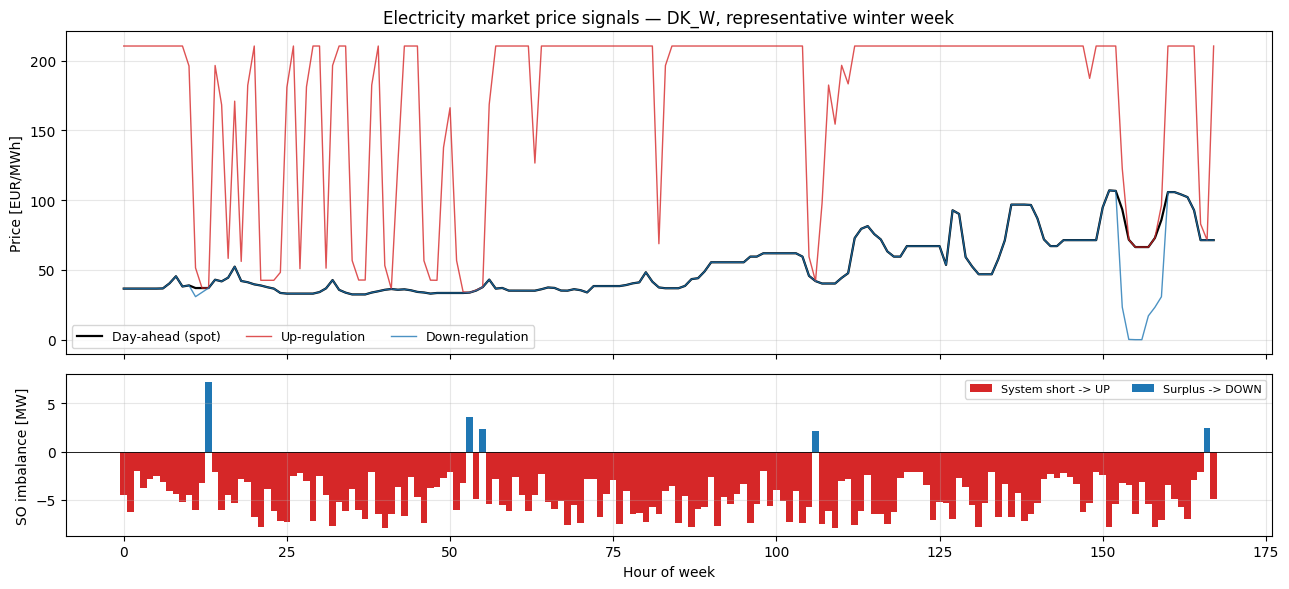

In [4]:
fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True,
                       gridspec_kw={"height_ratios": [2, 1]})
h = np.arange(N)
ax[0].plot(h, price,    color="black",     lw=1.6, label="Day-ahead (spot)")
ax[0].plot(h, price_up, color="tab:red",   lw=1.0, label="Up-regulation",   alpha=0.8)
ax[0].plot(h, price_dw, color="tab:blue",  lw=1.0, label="Down-regulation", alpha=0.8)
ax[0].set_ylabel("Price [EUR/MWh]"); ax[0].legend(ncol=3, fontsize=9)
ax[0].set_title(f"Electricity market price signals — {ZONE}, representative winter week")
ax[0].grid(alpha=0.3)

# SO imbalance: red bars = system short (UP needed), blue bars = surplus (DOWN needed)
ax[1].bar(h[SO_imb < 0], SO_imb[SO_imb < 0], color="tab:red",  width=1.0, label="System short -> UP")
ax[1].bar(h[SO_imb > 0], SO_imb[SO_imb > 0], color="tab:blue", width=1.0, label="Surplus -> DOWN")
ax[1].axhline(0, color="k", lw=0.6)
ax[1].set_ylabel("SO imbalance [MW]"); ax[1].set_xlabel("Hour of week")
ax[1].legend(ncol=2, fontsize=8); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Plot 2 — Day-ahead-only dispatch

With a single price signal the battery simply does **price arbitrage**: charge (negative net) when
prices are low, discharge into the peaks. The plant exports up to the grid limit.

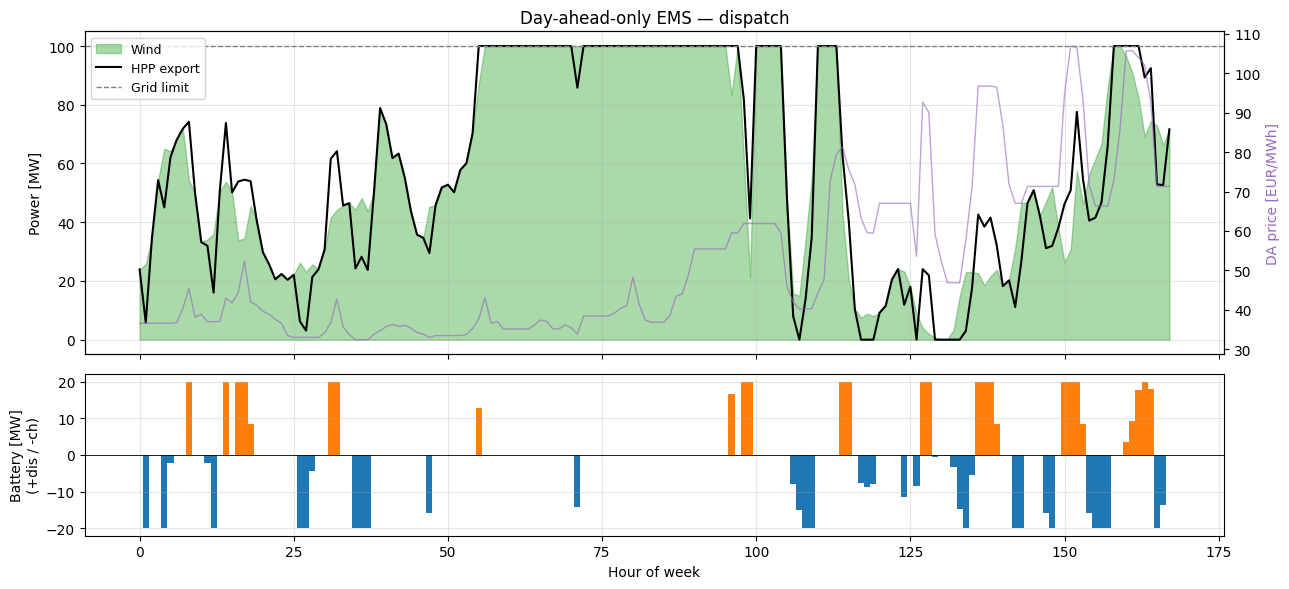

In [5]:
fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True,
                       gridspec_kw={"height_ratios": [2, 1]})
batt_da = da_res["P_dis"] - da_res["P_ch"]            # net battery power (+discharge / -charge)
ax[0].fill_between(h, 0, wind, color="tab:green", alpha=0.4, label="Wind")
ax[0].plot(h, da_res["P_HPP"], color="black", lw=1.5, label="HPP export")
ax[0].axhline(G_MW, color="grey", ls="--", lw=1, label="Grid limit")
ax2 = ax[0].twinx(); ax2.plot(h, price, color="tab:purple", lw=1, alpha=0.6, label="DA price")
ax2.set_ylabel("DA price [EUR/MWh]", color="tab:purple")
ax[0].set_ylabel("Power [MW]"); ax[0].legend(loc="upper left", fontsize=9)
ax[0].set_title("Day-ahead-only EMS — dispatch"); ax[0].grid(alpha=0.3)

ax[1].bar(h, batt_da, color=np.where(batt_da >= 0, "tab:orange", "tab:blue"), width=1.0)
ax[1].set_ylabel("Battery [MW]\n(+dis / -ch)"); ax[1].set_xlabel("Hour of week")
ax[1].axhline(0, color="k", lw=0.6); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Plot 3 — Day-ahead + balancing dispatch (revenue stacking)

Now the plant **also** sells regulation on top of its day-ahead schedule — but only in the
direction the system operator needs (the gating from Plot 1). Up-regulation (red) appears only in
hours the SO signalled a shortage.

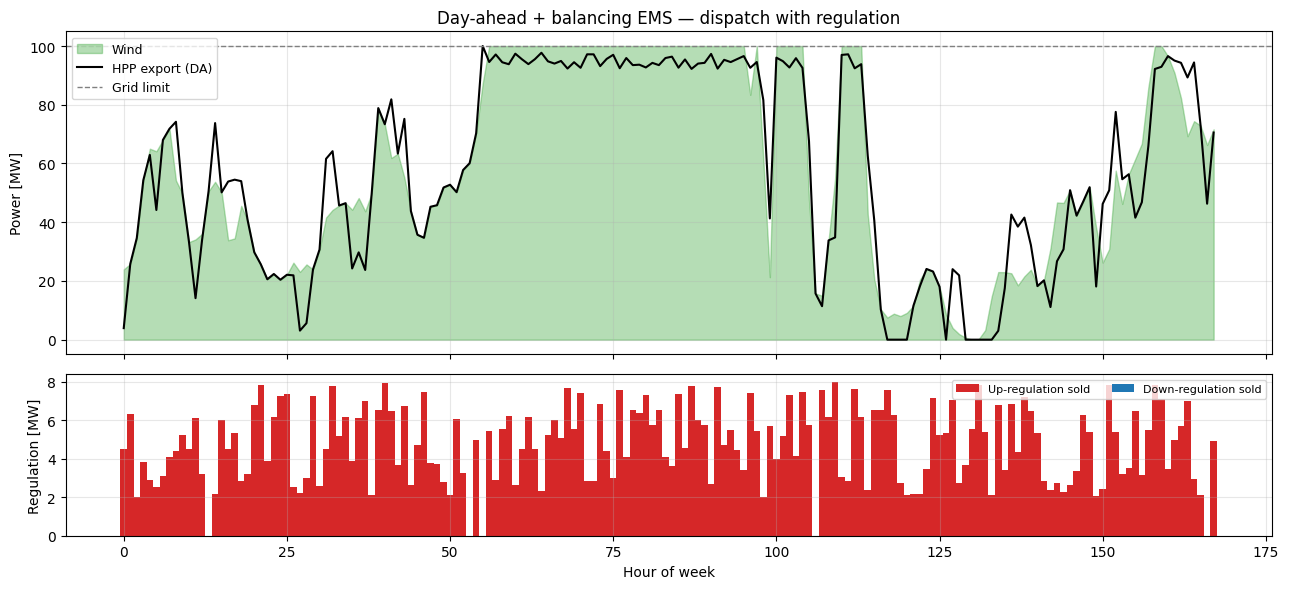

In [6]:
fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True,
                       gridspec_kw={"height_ratios": [2, 1]})
ax[0].fill_between(h, 0, wind, color="tab:green", alpha=0.35, label="Wind")
ax[0].plot(h, bm_res["P_HPP"], color="black", lw=1.5, label="HPP export (DA)")
ax[0].axhline(G_MW, color="grey", ls="--", lw=1, label="Grid limit")
ax[0].set_ylabel("Power [MW]"); ax[0].legend(loc="upper left", fontsize=9)
ax[0].set_title("Day-ahead + balancing EMS — dispatch with regulation"); ax[0].grid(alpha=0.3)

ax[1].bar(h, bm_res["P_up"],  color="tab:red",  width=1.0, label="Up-regulation sold")
ax[1].bar(h, -bm_res["P_dw"], color="tab:blue", width=1.0, label="Down-regulation sold")
ax[1].set_ylabel("Regulation [MW]"); ax[1].set_xlabel("Hour of week")
ax[1].axhline(0, color="k", lw=0.6); ax[1].legend(ncol=2, fontsize=8); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Plot 4 — Revenue stacking & capture price

The headline result: adding balancing-market participation lifts both **total revenue** and the
**capture price** (the dispatch-weighted average price the plant actually realises — a KPI EMERGE
uses explicitly and HyDesign does not report by default).

DA-only      : revenue    507,375 EUR | capture  51.6 EUR/MWh
DA+balancing : revenue    639,289 EUR | capture  66.0 EUR/MWh
  -> DA part 499,585 + regulation 139,704
  -> uplift +131,914 EUR (+26.0%)
  (week mean DA price 52.3 EUR/MWh)


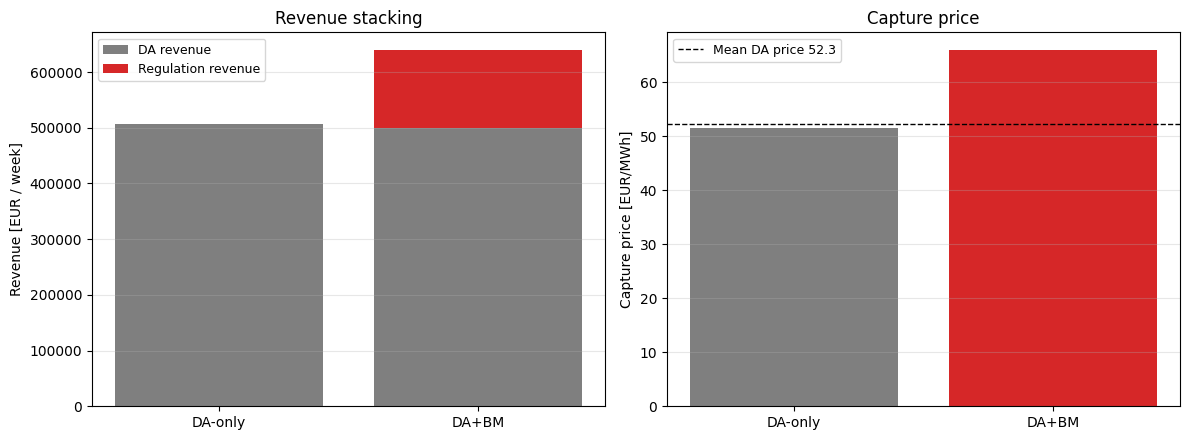

In [7]:
rev_da     = (da_res["P_HPP"]*price).sum()
rev_bm_da  = (bm_res["P_HPP"]*price).sum()
rev_bm_reg = (bm_res["P_up"]*price_up - bm_res["P_dw"]*price_dw).sum()
rev_bm_tot = rev_bm_da + rev_bm_reg
cap_da = rev_da     / da_res["P_HPP"].sum()
cap_bm = rev_bm_tot / bm_res["P_HPP"].sum()

print(f"DA-only      : revenue {rev_da:10,.0f} EUR | capture {cap_da:5.1f} EUR/MWh")
print(f"DA+balancing : revenue {rev_bm_tot:10,.0f} EUR | capture {cap_bm:5.1f} EUR/MWh")
print(f"  -> DA part {rev_bm_da:,.0f} + regulation {rev_bm_reg:,.0f}")
print(f"  -> uplift {rev_bm_tot-rev_da:+,.0f} EUR ({(rev_bm_tot/rev_da-1)*100:+.1f}%)")
print(f"  (week mean DA price {price.mean():.1f} EUR/MWh)")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].bar(["DA-only"], [rev_da], color="tab:gray", label="DA revenue")
ax[0].bar(["DA+BM"], [rev_bm_da], color="tab:gray")
ax[0].bar(["DA+BM"], [rev_bm_reg], bottom=[rev_bm_da], color="tab:red", label="Regulation revenue")
ax[0].set_ylabel("Revenue [EUR / week]"); ax[0].set_title("Revenue stacking")
ax[0].legend(fontsize=9); ax[0].grid(alpha=0.3, axis="y")

ax[1].bar(["DA-only","DA+BM"], [cap_da, cap_bm], color=["tab:gray","tab:red"])
ax[1].axhline(price.mean(), color="k", ls="--", lw=1, label=f"Mean DA price {price.mean():.1f}")
ax[1].set_ylabel("Capture price [EUR/MWh]"); ax[1].set_title("Capture price")
ax[1].legend(fontsize=9); ax[1].grid(alpha=0.3, axis="y")
plt.tight_layout(); plt.show()

## 5. The real co-optimisation — `ems_BM.py`'s two-settlement structure

The `ems_bm()` above **simplified** the model: it used one wind series and treated regulation as
add-on revenue. The production `ems_BM.py` is richer — it is a genuine **two-settlement**
co-optimisation. Two things it adds:

**(a) Two wind series.** `wind_t` is the **day-ahead forecast**; `wind_BM_t` is the later
**hour-ahead / actual** wind. The plant commits in DA against the forecast, then reality differs.

**(b) The commitment constraint** (line 1287 of `ems_BM.py`):
```python
# the basic assumption for the approach used to solve BM problem
solver.Add(P_HPP_BM_t[t] == P_HPP_t[t])
```
The balancing-stage delivery must equal the day-ahead commitment. With the two power balances:

$$P^{HPP}_t = \text{wind}^{DA}_t + P^{dis}_{SM} - P^{ch}_{SM} - P^{curt}_{SM}$$
$$P^{HPP}_t = \text{wind}^{HA}_t + P^{dis}_{BM} - P^{ch}_{BM} + P^{dis}_{SM} - P^{ch}_{SM} - P^{curt}_{BM} - P^{up} + P^{dwn} + P^{pen}$$

Subtracting them (the shared SM battery terms cancel) shows what regulation **physically is**:

$$\underbrace{P^{up}_t - P^{dwn}_t}_{\text{regulation sold}} \;\approx\;
\underbrace{(\text{wind}^{HA}_t - \text{wind}^{DA}_t)}_{\text{forecast error}}
\;+\; \text{BM battery action} \;-\; \underbrace{P^{pen}_t}_{\text{unserved}}$$

So a **forecast error** is absorbed by selling regulation, deploying the BM battery channel, or —
if nothing else covers it — paying an imbalance penalty `penalty_BM`. Because `P_HPP` (the DA bid)
is itself a free variable in the **same single MILP**, the day-ahead commitment is chosen already
knowing the balancing prices, the SO direction, and the actual wind. That joint choice is the
co-optimisation.

In [8]:
# Day-ahead forecast vs hour-ahead actual wind
wind_DA = wind.copy()                                   # forecast committed in the day-ahead market
rng = np.random.default_rng(7)
wind_HA = np.clip(wind_DA + rng.normal(0, 8, N), 0, P_WIND)  # actual realised wind (HA)
penalty_BM = 60.0                                       # EUR/MWh penalty for missing the DA commitment

def ems_bm_coopt(wind_DA, wind_HA, price, price_up, price_dw, SO_imb,
                 G_MW, P_batt, E_batt, eff, DoD, penalty_BM, fix_HPP=None):
    """Faithful ems_BM co-optimisation: two-settlement DA + balancing with commitment + penalty.
    Separate SM/BM battery channels share one SOC and one binary (no simultaneous charge/discharge).
    fix_HPP (optional): pin the day-ahead commitment P_HPP to given values (used for the
    here-and-now stochastic illustration in Section 6)."""
    N = len(price); nv = 10
    iH,iChS,iDiS,iChB,iDiB,iCuS,iCuB,iUp,iDw,iPen = range(10)   # 10 vars per timestep
    base = nv*N; iSOC = base; iZ = base+(N+1); ntot = iZ+N

    c = np.zeros(ntot)
    for t in range(N):
        c[nv*t+iH]   = -price[t]       # DA revenue
        c[nv*t+iUp]  = -price_up[t]    # paid for up-regulation
        c[nv*t+iDw]  = +price_dw[t]    # pay for down-regulation
        c[nv*t+iPen] = +penalty_BM     # imbalance penalty (cost of unserved commitment)

    lb = np.zeros(ntot); ub = np.full(ntot, np.inf)
    for t in range(N):
        ub[nv*t+iH] = G_MW
        ub[nv*t+iChS]=ub[nv*t+iDiS]=ub[nv*t+iChB]=ub[nv*t+iDiB]=P_batt
        ub[nv*t+iUp] = max(0.0, -SO_imb[t])   # SO gating: up-reg only when system short
        ub[nv*t+iDw] = max(0.0,  SO_imb[t])   # down-reg only when system surplus
        if fix_HPP is not None:               # pin the first-stage DA commitment
            lb[nv*t+iH] = ub[nv*t+iH] = fix_HPP[t]
    for t in range(N+1): ub[iSOC+t] = E_batt
    for t in range(N):   ub[iZ+t]   = 1
    integrality = np.zeros(ntot); integrality[iZ:iZ+N] = 1

    A,l,u = [],[],[]; row = lambda: np.zeros(ntot)
    for t in range(N):
        # (1) DA balance
        r=row(); r[nv*t+iH]=1; r[nv*t+iDiS]=-1; r[nv*t+iChS]=1; r[nv*t+iCuS]=1
        A.append(r); l.append(wind_DA[t]); u.append(wind_DA[t])
        # (2) BM balance with commitment P_HPP_BM == P_HPP substituted in
        r=row(); r[nv*t+iH]=1; r[nv*t+iDiB]=-1; r[nv*t+iChB]=1; r[nv*t+iDiS]=-1
        r[nv*t+iChS]=1; r[nv*t+iCuB]=1; r[nv*t+iUp]=1; r[nv*t+iDw]=-1; r[nv*t+iPen]=-1
        A.append(r); l.append(wind_HA[t]); u.append(wind_HA[t])
        # (3) grid cap incl. regulation, and (4) no reverse flow
        r=row(); r[nv*t+iH]=1; r[nv*t+iUp]=1; r[nv*t+iDw]=-1; A.append(r); l.append(-np.inf); u.append(G_MW)
        r=row(); r[nv*t+iH]=1; r[nv*t+iUp]=1; r[nv*t+iDw]=-1; A.append(r); l.append(0); u.append(np.inf)
    for t in range(N):
        # (5) shared SOC dynamics across BOTH battery channels
        r=row(); r[iSOC+t+1]=1; r[iSOC+t]=-1; r[nv*t+iChS]=-eff; r[nv*t+iChB]=-eff
        r[nv*t+iDiS]=1/eff; r[nv*t+iDiB]=1/eff; A.append(r); l.append(0); u.append(0)
        r=row(); r[iSOC+t]=1; A.append(r); l.append((1-DoD)*E_batt); u.append(np.inf)   # (6) SOC min
    r=row(); r[iSOC+0]=1; A.append(r); l.append(0.5*E_batt); u.append(0.5*E_batt)         # cyclic SOC
    r=row(); r[iSOC+N]=1; A.append(r); l.append(0.5*E_batt); u.append(0.5*E_batt)
    for t in range(N):
        # (7) one binary across both channels: no simultaneous charge & discharge
        r=row(); r[nv*t+iChS]=1; r[nv*t+iChB]=1; r[iZ+t]=P_batt;  A.append(r); l.append(-np.inf); u.append(P_batt)
        r=row(); r[nv*t+iDiS]=1; r[nv*t+iDiB]=1; r[iZ+t]=-P_batt; A.append(r); l.append(-np.inf); u.append(0)

    res = milp(c, constraints=LinearConstraint(np.array(A), l, u),
               integrality=integrality, bounds=Bounds(lb, ub))
    if res.x is None: return None
    x = res.x; g = lambda i: np.array([x[nv*t+i] for t in range(N)])
    return dict(P_HPP=g(iH), P_up=g(iUp), P_dw=g(iDw), P_pen=g(iPen),
                ch=g(iChS)+g(iChB), dis=g(iDiS)+g(iDiB),
                SOC=np.array([x[iSOC+t] for t in range(N+1)]), profit=-res.fun, status=res.status)

cop = ems_bm_coopt(wind_DA, wind_HA, price, price_up, price_dw, SO_imb,
                   G_MW, P_batt, E_batt, eff, DoD, penalty_BM)
print("Co-optimisation solve status:", cop["status"], "(0 = optimal)")

Co-optimisation solve status: 0 (0 = optimal)


## Plot 5 — How the co-optimisation resolves a forecast error

Every hour the plant committed `P_HPP` (a free DA variable) against the **forecast** `wind_DA`.
When the **actual** `wind_HA` arrives, the gap `wind_HA − wind_DA` is closed by up-regulation
(surplus hours), down-regulation, the BM battery, or — last resort — an imbalance **penalty**.
The bottom panel decomposes that gap.

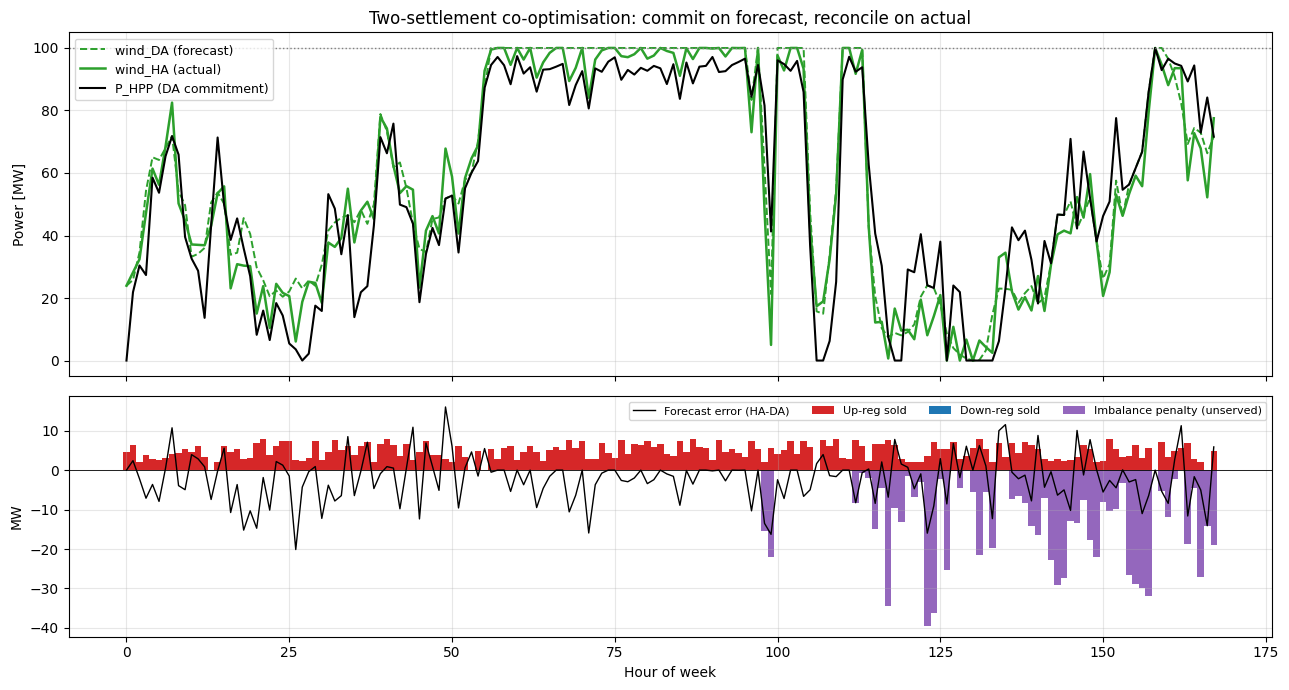

Worked example - the 3 hours where actual wind fell most short of the forecast:

  h 26: committed P_HPP=  3.6  wind_DA= 26.2 -> wind_HA=  6.1 (error -20.1)  |  battery dis= 0.0 up= 2.5 dw= 0.0 penalty= 0.0 MW
  h 99: committed P_HPP= 41.3  wind_DA= 21.3 -> wind_HA=  5.0 (error -16.3)  |  battery dis=20.0 up= 5.7 dw= 0.0 penalty=22.0 MW
  h123: committed P_HPP= 24.1  wind_DA= 24.1 -> wind_HA=  8.1 (error -16.0)  |  battery dis= 0.0 up= 3.5 dw= 0.0 penalty=39.5 MW

DA revenue 499,907  +  regulation 139,134  -  penalty 45,694  =  net 593,348 EUR


In [9]:
fe = wind_HA - wind_DA                                  # forecast error (actual - committed)
fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True, gridspec_kw={"height_ratios":[2,1.4]})

ax[0].plot(h, wind_DA, color="tab:green", lw=1.4, ls="--", label="wind_DA (forecast)")
ax[0].plot(h, wind_HA, color="tab:green", lw=1.8, label="wind_HA (actual)")
ax[0].plot(h, cop["P_HPP"], color="black", lw=1.5, label="P_HPP (DA commitment)")
ax[0].axhline(G_MW, color="grey", ls=":", lw=1)
ax[0].set_ylabel("Power [MW]"); ax[0].legend(loc="upper left", fontsize=9)
ax[0].set_title("Two-settlement co-optimisation: commit on forecast, reconcile on actual")
ax[0].grid(alpha=0.3)

# Decompose how each hour's forecast error is absorbed
ax[1].bar(h, cop["P_up"],  color="tab:red",   width=1.0, label="Up-reg sold")
ax[1].bar(h, -cop["P_dw"], color="tab:blue",  width=1.0, label="Down-reg sold")
ax[1].bar(h, -cop["P_pen"],color="tab:purple",width=1.0, label="Imbalance penalty (unserved)")
ax[1].plot(h, fe, color="black", lw=1.0, label="Forecast error (HA-DA)")
ax[1].axhline(0, color="k", lw=0.6)
ax[1].set_ylabel("MW"); ax[1].set_xlabel("Hour of week")
ax[1].legend(ncol=4, fontsize=8); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# A worked numeric example: pick the 3 largest-deficit hours
deficit_hours = np.argsort(fe)[:3]
print("Worked example - the 3 hours where actual wind fell most short of the forecast:\n")
for t in sorted(deficit_hours):
    print(f"  h{t:3d}: committed P_HPP={cop['P_HPP'][t]:5.1f}  wind_DA={wind_DA[t]:5.1f} -> "
          f"wind_HA={wind_HA[t]:5.1f} (error {fe[t]:+5.1f})  |  battery dis={cop['dis'][t]:4.1f} "
          f"up={cop['P_up'][t]:4.1f} dw={cop['P_dw'][t]:4.1f} penalty={cop['P_pen'][t]:4.1f} MW")
rev_DA=(cop["P_HPP"]*price).sum(); rev_reg=(cop["P_up"]*price_up-cop["P_dw"]*price_dw).sum()
pen=(cop["P_pen"]*penalty_BM).sum()
print(f"\nDA revenue {rev_DA:,.0f}  +  regulation {rev_reg:,.0f}  -  penalty {pen:,.0f}  =  net {cop['profit']:,.0f} EUR")

## 6. The uncertainty / sequential treatment — HiFiEMS (`ems_hifi.py`)

`ems_BM.py` co-optimises both markets in **one shot with perfect foresight** — it assumes the
actual wind, balancing prices and SO direction are all known when committing the DA bid. That is an
optimistic upper bound. The **HiFiEMS** package (`hydesign/HiFiEMS/`) instead models the real
**sequential, information-revealing** process.

**Sequential rolling structure** (`EMS_assembly.py`, the `while day_num:` loop chains three stages):

| Stage | Module | Decision | Information available |
|---|---|---|---|
| **SMOpt** | Spot-Market Opt | Day-ahead bid `P_HPP_SM_k` | DA **forecasts** only |
| **BMOpt** | Balancing-Market Opt | Up/down regulation offers | Hour-ahead forecasts (intra-day) |
| **RDOpt** | Re-Dispatch Opt | Real-time setpoints | RT forecasts + **measurements** |

Each stage sees *more* information than the last — the code keeps **separate** `DA_wind_forecast`,
`HA_wind_forecast`, `RT_wind_forecast` and `Wind_measurement` series, exactly mirroring how data
actually arrives.

**Uncertainty modules** — `SMOpt` can be swapped (the `config` dict picks the `.py` file):

| File | Method | What it optimises |
|---|---|---|
| `DO.py` | Deterministic | single forecast (like `ems_BM`) |
| `SO.py` | **Stochastic** | expected value over weighted **scenarios** |
| `RO.py` | Robust | worst-case over an uncertainty set |
| `DRO.py` | Distributionally robust | worst-case over a set of distributions |

**The two-stage stochastic program** (`SO.py`): the DA bid `P_HPP_SM_k` is a **first-stage,
scenario-independent "here-and-now"** decision; the regulation/imbalance recourse
`delta[s,i]`, `tau[s,i]` is **second-stage "wait-and-see"** per scenario `i`. The objective is the
**probability-weighted expectation**:

$$\max \; \sum_i \text{prob}_i \Big[\, \text{SP}_{i,k}\,P^{SM}_k
\;+\; \text{RP}_{i,s}\,\Delta_{s,i} \;-\; C_{dev}\,\tau_{s,i} \,\Big]$$

i.e. one committed bid that performs best **on average** across all wind/price scenarios, instead
of one bid tuned to a single assumed future.

The cell below quantifies that difference using our own model.

Perfect-foresight (ems_BM upper bound): mean   187,313 EUR  [182,920..189,407]
Here-and-now commitment (HiFiEMS SO)  : mean   182,996 EUR  [178,494..185,131]
Value of perfect information (the gap) :     4,317 EUR (2.4% optimistic)


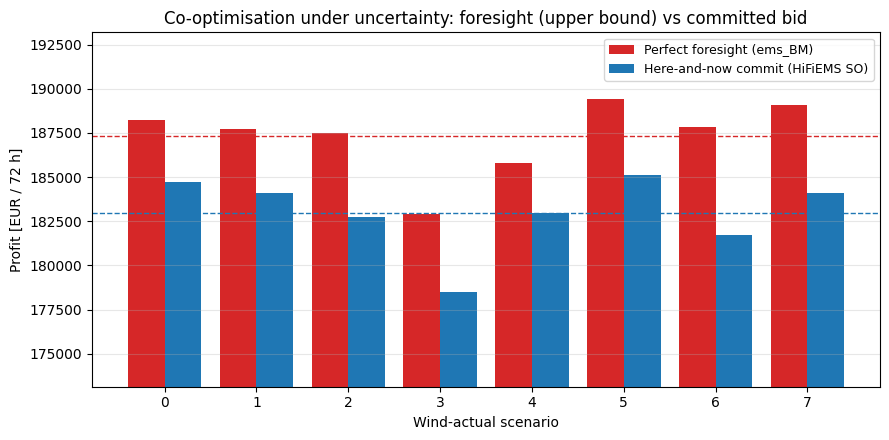

In [10]:
# Build K wind-actual scenarios around the forecast (a short 72 h window keeps this fast)
sl2 = slice(24*10, 24*13); N2 = 72
price2  = da.iloc[sl2].reset_index(drop=True).values
pup2    = up.iloc[sl2].reset_index(drop=True).values
pdw2    = dwn.iloc[sl2].reset_index(drop=True).values
wDA2    = P_WIND * power_curve(wts["WS_150"].iloc[:N2].values)
SO2     = np.where(pup2 > pdw2, -1.0, 1.0) * rng.uniform(2, 8, N2)
K = 8
scen = [np.clip(wDA2 + rng.normal(0, 8, N2), 0, P_WIND) for _ in range(K)]

# (a) Perfect foresight  — what ems_BM assumes: optimise knowing each actual (upper bound)
pf = np.array([ems_bm_coopt(wDA2, w, price2, pup2, pdw2, SO2,
                            G_MW, P_batt, E_batt, eff, DoD, penalty_BM)["profit"] for w in scen])

# (b) Here-and-now — what HiFiEMS SO does: commit ONE DA bid (from the forecast), then live each scenario
commit = ems_bm_coopt(wDA2, wDA2, price2, pup2, pdw2, SO2,
                      G_MW, P_batt, E_batt, eff, DoD, penalty_BM)["P_HPP"]
hn = np.array([ems_bm_coopt(wDA2, w, price2, pup2, pdw2, SO2, G_MW, P_batt, E_batt, eff, DoD,
                            penalty_BM, fix_HPP=commit)["profit"] for w in scen])

print(f"Perfect-foresight (ems_BM upper bound): mean {pf.mean():9,.0f} EUR  [{pf.min():,.0f}..{pf.max():,.0f}]")
print(f"Here-and-now commitment (HiFiEMS SO)  : mean {hn.mean():9,.0f} EUR  [{hn.min():,.0f}..{hn.max():,.0f}]")
print(f"Value of perfect information (the gap) : {pf.mean()-hn.mean():9,.0f} EUR "
      f"({(pf.mean()/hn.mean()-1)*100:.1f}% optimistic)")

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(K)
ax.bar(x-0.2, pf, 0.4, color="tab:red",  label="Perfect foresight (ems_BM)")
ax.bar(x+0.2, hn, 0.4, color="tab:blue", label="Here-and-now commit (HiFiEMS SO)")
ax.axhline(pf.mean(), color="tab:red",  ls="--", lw=1)
ax.axhline(hn.mean(), color="tab:blue", ls="--", lw=1)
ax.set_xlabel("Wind-actual scenario"); ax.set_ylabel("Profit [EUR / 72 h]")
ax.set_title("Co-optimisation under uncertainty: foresight (upper bound) vs committed bid")
ax.legend(fontsize=9); ax.grid(alpha=0.3, axis="y")
ax.set_ylim(min(hn.min(), pf.min())*0.97, pf.max()*1.02)
plt.tight_layout(); plt.show()

## Summary — how HyDesign models electricity markets

1. **No unified market model.** Markets are **interchangeable EMS modules**, picked per study:
   `ems.py` (spot), `ems_BM.py` (spot + balancing), `ems_P2X.py` (fixed PPA / H₂ offtake),
   `ems_constant_output.py` (firm load).
2. **Only `ems_BM.py` co-optimises two markets at once.** It carries separate spot and balancing
   variables, stacks DA + up − down revenue, and gates regulation direction with the
   system-operator imbalance signal `SO_imbalance_t`.
3. **Price-taker everywhere.** All prices are exogenous inputs; the plant never moves the price.
4. **One grid node, no congestion.** Every formulation uses a single `hpp_grid_connection` scalar
   and one price node — there is **no nodal / congestion pricing** (matches the "not grid
   congestion pricing" caveat in the comparison deck).
5. **Capture price** is a natural post-processing KPI (shown above) but HyDesign does not report it
   by default — this is one place EMERGE's dispatch-aware KPIs are more explicit.
6. **The co-optimisation** (`ems_BM.py`, Section 5) is a single MILP where the day-ahead bid
   `P_HPP` is a free variable solved jointly with the balancing response, linked by a shared
   battery SOC and the commitment constraint `P_HPP_BM == P_HPP`. A **forecast error**
   (`wind_HA − wind_DA`) is absorbed by regulation, the BM battery, or an imbalance penalty.
7. **Uncertainty** (`HiFiEMS`, Section 6): `ems_BM` is deterministic **perfect-foresight** (an
   optimistic upper bound). HiFiEMS models the real **sequential** process — SMOpt → BMOpt → RDOpt,
   each stage seeing more information — and offers **stochastic / robust / distributionally-robust**
   first-stage bids (`SO.py` / `RO.py` / `DRO.py`). The gap between foresight and a here-and-now
   commitment (Section 6 plot) is the quantified **value of treating uncertainty**.

> The re-implementations here use `scipy.optimize.milp` so the notebook runs without a CPLEX
> licence. The production code uses **CPLEX** (`ems.py`) and **OR-Tools / SCIP** (`ems_BM.py`),
> batches the horizon into weekly windows, and adds battery-fluctuation and peak-firmness
> penalties — omitted here for clarity. The HiFiEMS comparison in Section 6 is illustrated with our
> own model; the production HiFiEMS additionally runs at sub-hourly dispatch intervals with
> scenario files and battery degradation in the objective.